# Random Field Plots

In [38]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]  
sys.path.insert(0, str(PROJECT_ROOT))
project_root = Path("/home/philipp-felsen/Desktop/PyUQFEM")
sys.path.insert(0, str(project_root))
import numpy as np


from permeability.lognormalField import LognormalField
from permeability.lognormalInclusion import LognormalInclusion
from permeability.movingInclusion import LognormalMovingInclusion
from permeability.multiphase import MultiphaseField
from permeability.randomShapeField import RandomShapeField

from matplotlib.ticker import LogLocator, NullFormatter, MaxNLocator
import matplotlib.pyplot as plt

font_size=12
title_size=14
label_size=13
tick_size=11
legend_size=10
dpi=300


plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})


In [39]:
stochDim = 15
mu = 1.0
sigma = 0.25
corrLength = 0.1
numberOfPhases = 2
phaseValues=[2,3]
inclusionValues=(2,3)
movingInclusionValue=3.0
fields = ["LognormalField","LognormalInclusion", "LognormalMovingInclusion", "RandomShapeField", "MultiphaseField"]
seed = 1


def make_field(field_type):
    if field_type == "LognormalField":
        return LognormalField(
            dim=stochDim,
            corrLength=corrLength,
            mu=mu,
            sigma=sigma,
        )
    
    if field_type == "LognormalInclusion":
        return LognormalInclusion(
        dim=stochDim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
        inclusionValues=inclusionValues
    )

    if field_type == "LognormalMovingInclusion":
        return LognormalMovingInclusion(
        dim=stochDim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
        inclusionValue=movingInclusionValue,
        maxShift=(0.40, 0.40) # Can move anywhere inside the box
    )

    if field_type == "MultiphaseField":
        return MultiphaseField(
        dim=stochDim,
        numberOfPhases=numberOfPhases,
        phaseValues=phaseValues,
        phaseBoundaries=[np.exp(mu)],
        corrLength=corrLength,
        mu=mu,
        sigma=sigma
    )

    if field_type == "RandomShapeField":
        return RandomShapeField(
        dim=stochDim,
        inclusionValue=3.0,
        backgroundValue = 2.0,
        center=(0.5, 0.5),
        baseRadius=0.25,
        deformationStrength=0.5,
    )

def sampleXi(seed):
    rng = np.random.default_rng(seed)
    return rng.uniform(-1.0, 1.0, stochDim)


In [40]:
def field_caption(field_type):
    names = {
        "LognormalField": "Lognormal field",
        "LognormalInclusion": "Lognormal field with fixed inclusions",
        "LognormalMovingInclusion": "Lognormal field with moving inclusion",
        "MultiphaseField": "Multiphase field",
        "RandomShapeField": "Random shape field",
    }
    return names[field_type]

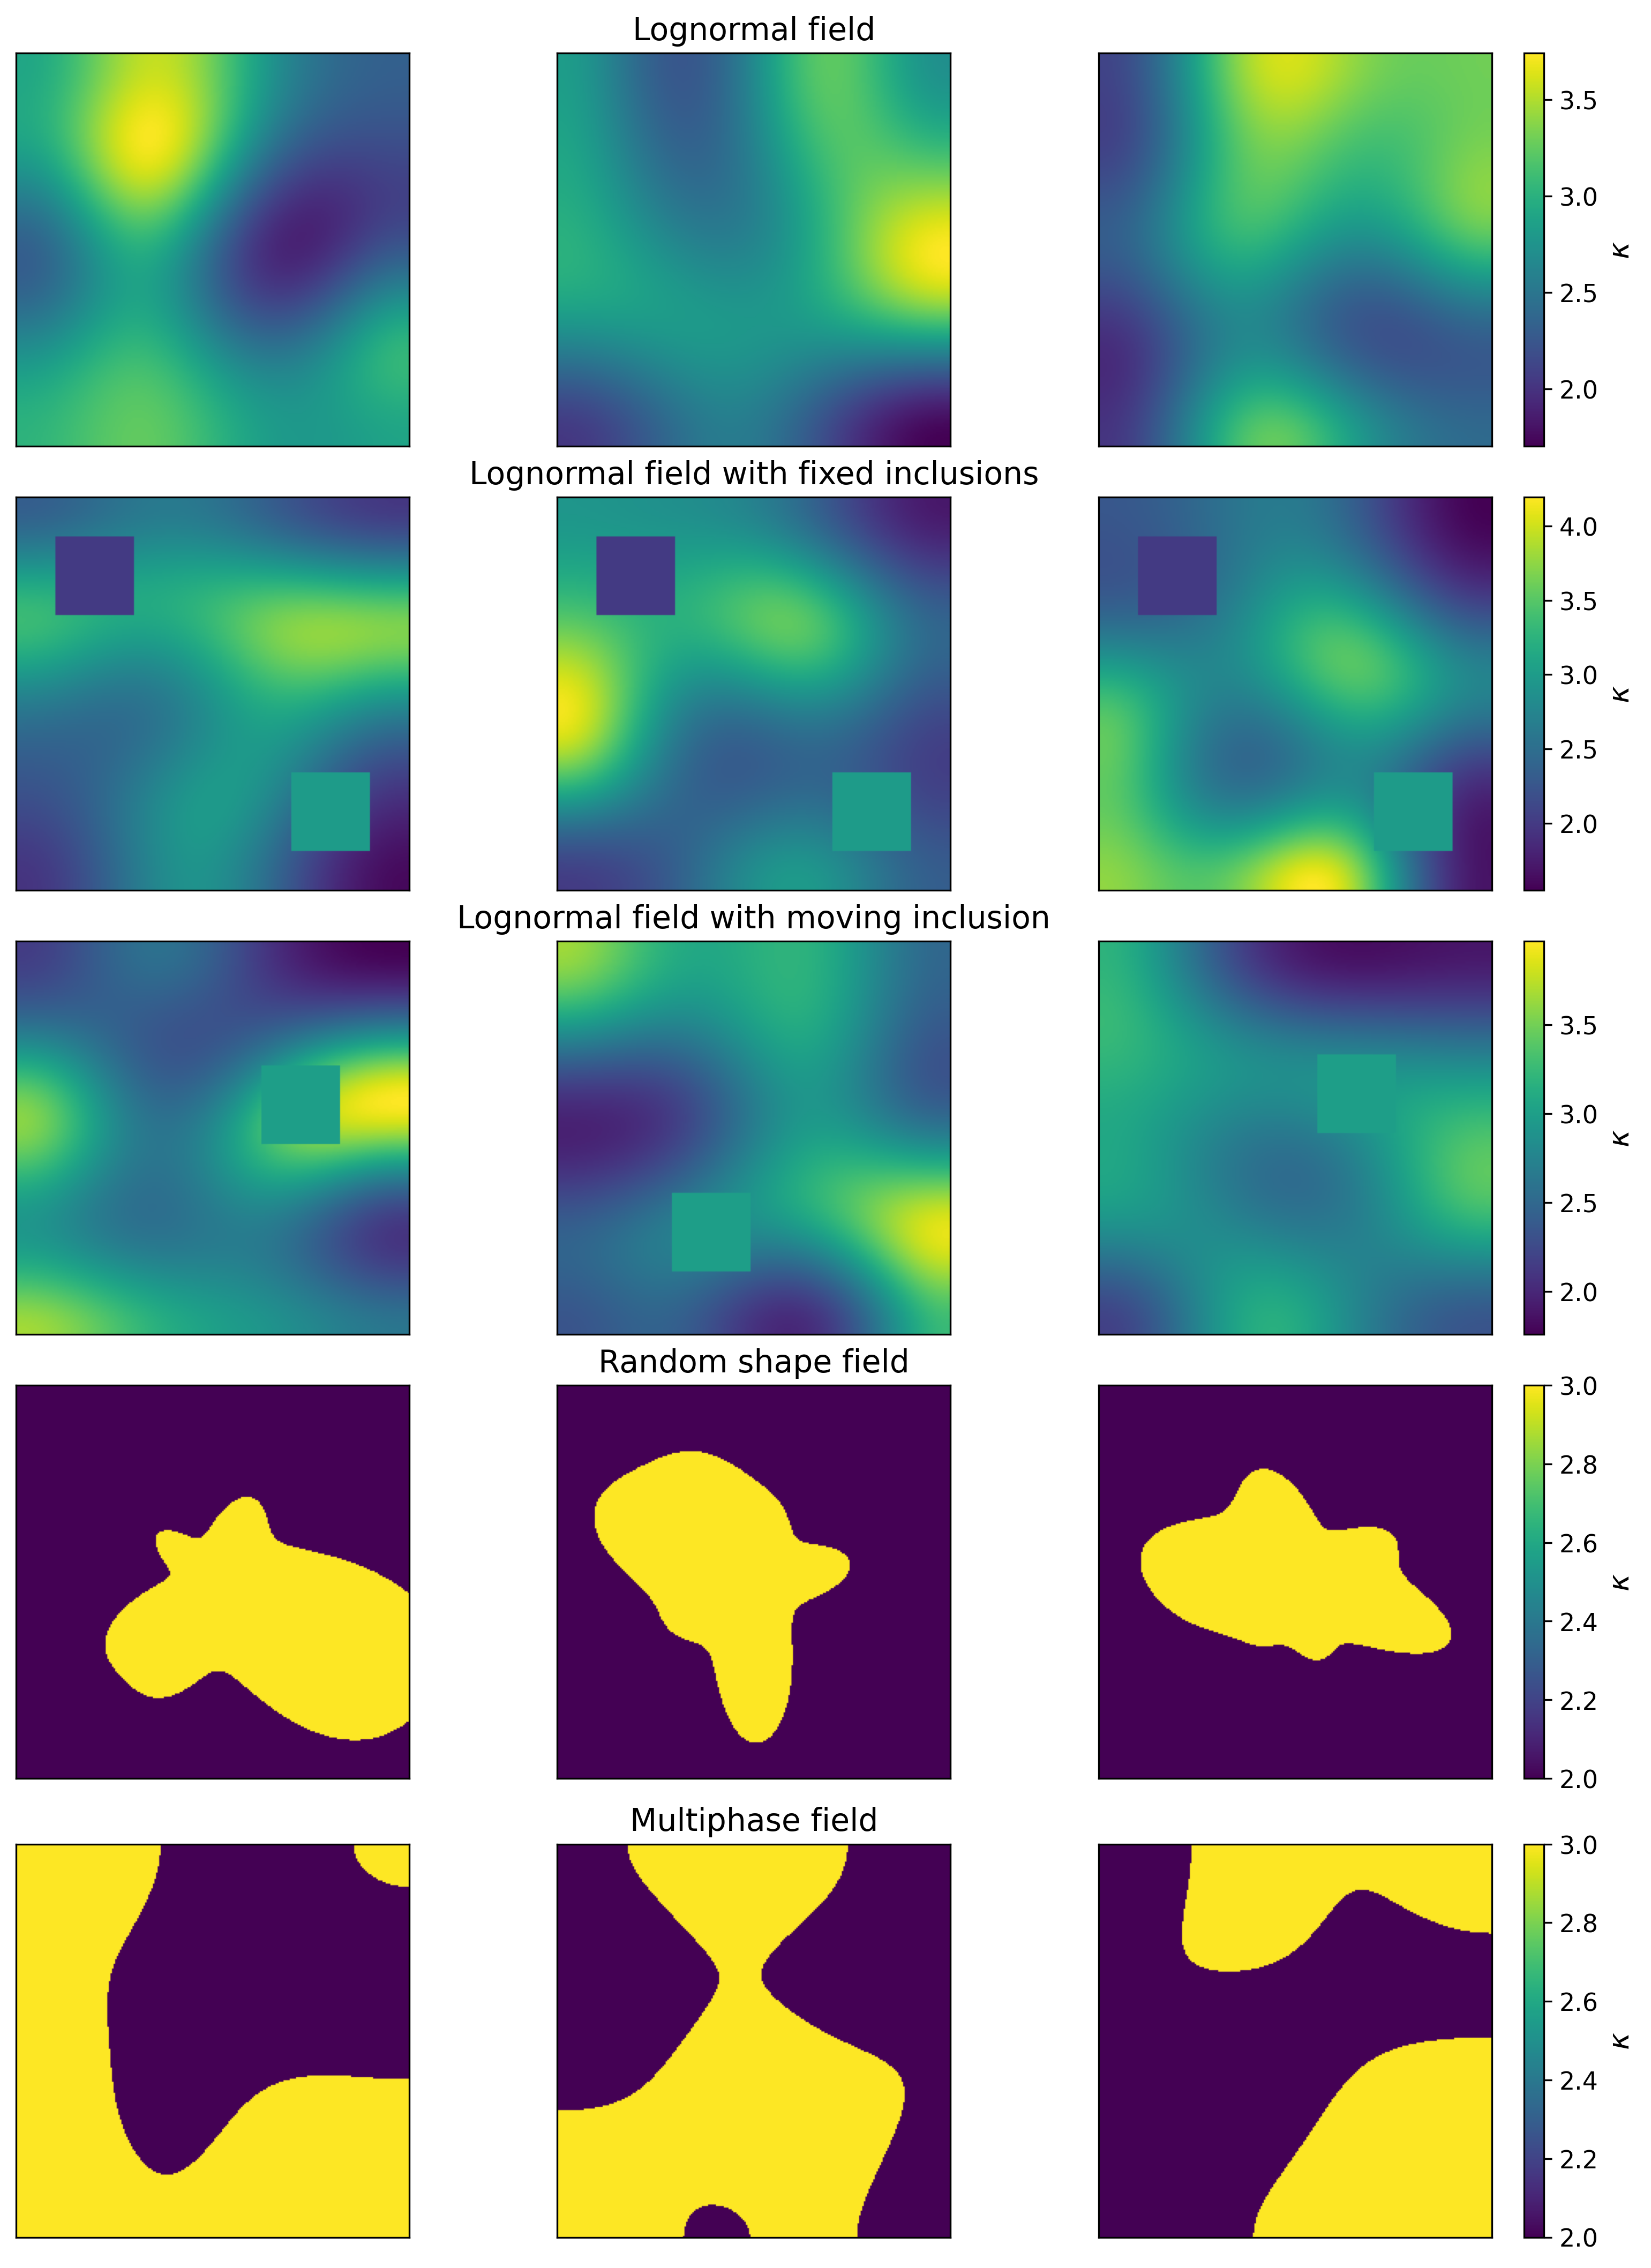

In [42]:
# Grid
n = 250
x = np.linspace(0.0, 1.0, n)
y = np.linspace(0.0, 1.0, n)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(
    nrows=len(fields),
    ncols=3,
    figsize=(11, 14),
    constrained_layout=True,
)

for row, field_type in enumerate(fields):
    field = make_field(field_type)

    Ks = []
    for col in range(3):
        xi = sampleXi(seed + 10*row + col)
        Ks.append(field.evaluate(X, Y, xi=xi))

    # Global limits for this row
    vmin = min(K.min() for K in Ks)
    vmax = max(K.max() for K in Ks)

    # Plot using the same normalization
    ims = []
    for col, K in enumerate(Ks):
        ax = axes[row, col]
        im = ax.imshow(
            K,
            origin="lower",
            extent=(0, 1, 0, 1),
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ims.append(im)

        ax.set_xticks([])
        ax.set_yticks([])

        if col == 1:
            ax.set_title(field_caption(field_type))

    # One colorbar for the whole row
    cbar = fig.colorbar(
        ims[0],            
        ax=axes[row, :],
        location="right",
        pad=0.02,
        fraction=0.03,
    )
    cbar.set_label(r"$\kappa$")

plt.show()